In [1]:
import torch
import os, sys

from utils.dataset_utils import get_taxi_data
import polars as pl

sys.path.insert(0, os.path.abspath(".."))


MAC_DIR = '/Users/igwanhyeong/PycharmProjects/paper_research/'
WINDOW_DIR = 'C:/Users/USER/PycharmProjects/paper_research/'

if sys.platform == 'win32':
    DIR = WINDOW_DIR
    print(torch.cuda.is_available())
    print(torch.cuda.device_count())
    print(torch.version.cuda)
    print(torch.__version__)
    print(torch.cuda.get_device_name(0))
    print(torch.__version__)
else:
    DIR = MAC_DIR

True
1
12.8
2.9.0.dev20250716+cu128
NVIDIA GeForce RTX 5080
2.9.0.dev20250716+cu128
True
1
12.8
2.9.0.dev20250716+cu128
NVIDIA GeForce RTX 5080
2.9.0.dev20250716+cu128


In [2]:
def build_sample(
        df: pl.DataFrame,
        *,
        pickup_time_col: str = 'tpep_pickup_datetime',
        mark_col: str = 'payment_type',
        lon_col: str = 'pickup_longitude',
        lat_col: str = 'pickup_latitude',
        grid_size_deg: float = 0.01,
        min_seq_len: int = 20,
        max_seq_len: int = 300,
        time_unit: str = 's'
) -> list[tuple[list[int], list[float]]]:
    """
    :return:
        samples: List[(marks_list, times_list)]
            - marks_list: List[int]
            - times_list: List[float] (epoch seconds)
    """
    df2 = (
        df.with_columns([
            pl.col(pickup_time_col)
              .str.strptime(pl.Datetime, strict = False)
              .alias('pickup_dt'),
            pl.col(mark_col).cast(pl.Int64).alias('mark'),
            pl.col(lon_col).cast(pl.Float64).alias('plon'),
            pl.col(lat_col).cast(pl.Float64).alias('plat'),
          ])
          .filter(
            pl.col('pickup_dt').is_not_null()
            & pl.col('mark').is_not_null()
            & pl.col('plon').is_not_null()
            & pl.col('plat').is_not_null()
          )
          .with_columns([
            (pl.col('plon') / grid_size_deg).floor().cast(pl.Int64).alias('gx'),
            (pl.col('plat') / grid_size_deg).floor().cast(pl.Int64).alias('gy'),
          ])
          .with_columns(
            (pl.col('gx').cast(pl.Utf8) + pl.lit('_') + pl.col('gy').cast(pl.Utf8)).alias('entity_id')
          )
          .with_columns(
            pl.col('pickup_dt').dt.epoch(time_unit = time_unit).cast(pl.Int64).alias('t_epoch')
          )
          .select(['entity_id', 't_epoch', 'mark']).sort(['entity_id', 't_epoch'])
          .group_by('entity_id', maintain_order = True)
          .agg([
            pl.col('mark').alias('marks'),
            pl.col('t_epoch').alias('times'),
            pl.len().alias('seq_len'),
          ])
          .filter(pl.col('seq_len') >= min_seq_len)
          .select(['marks', 'times', 'seq_len'])
          .with_columns([
            pl.col('marks').list.slice(0, max_seq_len).alias('marks'),
            pl.col('times').list.slice(0, max_seq_len).alias('times'),
          ])
    )

    samples = []
    for row in df2.iter_rows(named = True):
        marks_list = row['marks']
        times_list = row['times']

        if time_unit == 'ms':
            times_list = [t / 1000.0 for t in times_list]
        else:
            times_list = [float(t) for t in times_list]

        marks_list = [int(m) for m in marks_list]
        samples.append((marks_list, times_list))

    return samples

In [3]:
df = pl.read_parquet(DIR + 'sample_data/yellow_trip.parquet')
samples = build_sample(df)
print('num samples: ', len(samples), 'example lens: ', len(samples[0][0]))

num samples:  499 example lens:  258


In [38]:
from data_loader.event_seq_data_module import remap_marks_in_samples, make_loaders_from_samples

samples, mark_map = remap_marks_in_samples(samples)
K = len(mark_map)
print("K (num real marks):", K)
print("original->remapped mapping (head):", dict(list(mark_map.items())[:10]))

# dt를 "시간 단위"로 축소 + clip을 4시간으로 (원하면 조정)
train_loader, val_loader, pad_mark = make_loaders_from_samples(
    samples,
    K=K,
    batch_size=128,
    val_ratio=0.1,
    seed=42,
    dt_scale=60.0,     # seconds -> hours
    dt_clip_scaled=500.0,  # 4시간 이상은 4로 자름 (scaled) -> 12시간으로 변경
)


marks_b, dts_b, mask_b = next(iter(train_loader))
print("batch marks:", marks_b.shape, marks_b.dtype, "pad_mark:", pad_mark)
print("batch dts:", dts_b.shape, dts_b.dtype)
print("batch mask:", mask_b.shape, mask_b.dtype)
print("valid steps (approx):", int(mask_b[:, 1:].sum()))

K (num real marks): 4
original->remapped mapping (head): {0: 0, 1: 1, 2: 2, 3: 3}
batch marks: torch.Size([128, 300]) torch.int64 pad_mark: 4
batch dts: torch.Size([128, 300]) torch.float32
batch mask: torch.Size([128, 300]) torch.bool
valid steps (approx): 20335


In [39]:
from utils.bptt_utils import train_one_epoch, eval_one_epoch
from models.recurrent_marked_temporal_point_process.rmtpp import RMTPP
from models.recurrent_marked_temporal_point_process.config import RMTPPConfig
device = "cuda" if torch.cuda.is_available() else "cpu"
cfg = RMTPPConfig(
    num_marks=K + 1,
    mark_emb_dim=32,
    rnn_hidden_dim=128,
    rnn_type="gru",
    dropout=0.0,
    exp_clamp=20.0,
    w_min=1e-3,
    eps=1e-8,
)
model = RMTPP(cfg).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)

train_metrics = train_one_epoch(model, train_loader, optimizer, device)
val_metrics = eval_one_epoch(model, val_loader, device)

print("[train]", train_metrics)
print("[val]  ", val_metrics)

[train] {'nll': 78562.73697916667, 'nll_marker': 1.6461238861083984, 'nll_time': 78561.09114583333, 'batches': 3}
[val]   {'nll': 96055.9453125, 'nll_marker': 1.6373974084854126, 'nll_time': 96054.3046875, 'batches': 1}


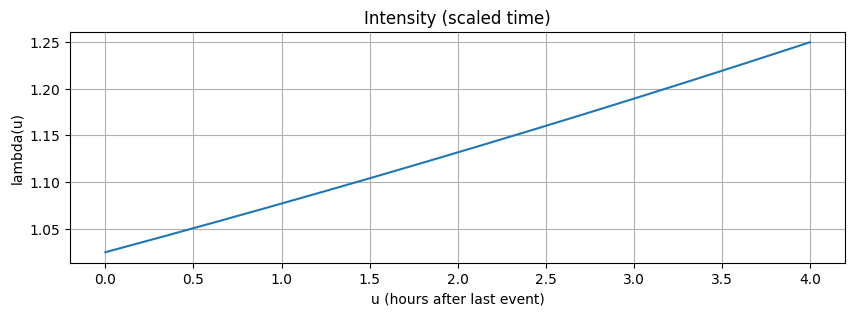

In [40]:
import matplotlib.pyplot as plt
import torch

model.eval()

marks, dts, mask = next(iter(val_loader))
marks = marks.to(device); dts = dts.to(device); mask = mask.to(device)

i = 0
L = int(mask[i].sum().item())
marks_i = marks[i:i+1, :L]
dts_i = dts[i:i+1, :L]

with torch.no_grad():
    h = model.forward_hidden(marks_i, dts_i)
    h_last = h[:, -1, :]

def intensity_curve(model, h_last, u_max=4.0, n=200):
    u = torch.linspace(0.0, u_max, n, device=h_last.device)
    w = model._w_pos()
    a = torch.clamp(model.v_t(h_last).squeeze(-1) + model.b_t, max=model.cfg.exp_clamp)
    lam = torch.exp(torch.clamp(a + w * u, max=model.cfg.exp_clamp))
    return u.detach().cpu().numpy(), lam.detach().cpu().numpy()

u, lam = intensity_curve(model, h_last, u_max=4.0, n=200)
plt.figure(figsize=(10, 3))
plt.plot(u, lam)
plt.xlabel("u (hours after last event)")
plt.ylabel("lambda(u)")
plt.title("Intensity (scaled time)")
plt.grid(True)
plt.show()


## 10 Epoch 돌리기

In [41]:
import math
import matplotlib.pyplot as plt

num_epochs = 30
history = {
    "train_nll": [],
    "train_nll_marker": [],
    "train_nll_time": [],
    "val_nll": [],
    "val_nll_marker": [],
    "val_nll_time": [],
}

for ep in range(1, num_epochs + 1):
    train_metrics = train_one_epoch(model, train_loader, optimizer, device)
    val_metrics = eval_one_epoch(model, val_loader, device)

    history["train_nll"].append(train_metrics["nll"])
    history["train_nll_marker"].append(train_metrics["nll_marker"])
    history["train_nll_time"].append(train_metrics["nll_time"])

    history["val_nll"].append(val_metrics["nll"])
    history["val_nll_marker"].append(val_metrics["nll_marker"])
    history["val_nll_time"].append(val_metrics["nll_time"])

    print(
        f"[{ep:02d}] "
        f"train nll={train_metrics['nll']:.4f} (m={train_metrics['nll_marker']:.4f}, t={train_metrics['nll_time']:.4f}) | "
        f"val nll={val_metrics['nll']:.4f} (m={val_metrics['nll_marker']:.4f}, t={val_metrics['nll_time']:.4f})"
    )


[01] train nll=68697.3047 (m=1.6339, t=68695.6693) | val nll=85395.7812 (m=1.6233, t=85394.1562)
[02] train nll=64690.9154 (m=1.6195, t=64689.2969) | val nll=76028.1797 (m=1.6073, t=76026.5703)
[03] train nll=55719.6523 (m=1.6032, t=55718.0482) | val nll=67815.2344 (m=1.5876, t=67813.6484)
[04] train nll=49261.8906 (m=1.5818, t=49260.3086) | val nll=60554.2617 (m=1.5631, t=60552.6992)
[05] train nll=44102.5234 (m=1.5571, t=44100.9661) | val nll=54061.6133 (m=1.5346, t=54060.0781)
[06] train nll=39682.9349 (m=1.5265, t=39681.4089) | val nll=48208.9531 (m=1.5025, t=48207.4492)
[07] train nll=35800.7083 (m=1.4931, t=35799.2155) | val nll=42923.3750 (m=1.4669, t=42921.9062)
[08] train nll=30608.4297 (m=1.4568, t=30606.9720) | val nll=38154.0430 (m=1.4262, t=38152.6172)
[09] train nll=28991.8164 (m=1.4108, t=28990.4049) | val nll=33861.4453 (m=1.3814, t=33860.0625)
[10] train nll=25864.9928 (m=1.3656, t=25863.6276) | val nll=30011.1445 (m=1.3324, t=30009.8125)
[11] train nll=22548.3952 (m=1

## Training Graph
### 1. Training NLL & Validation NLL Curve
### 2. Training NLL Marker & Validation NLL Marker Curve
### 3. Training NLL Time & Validation NLL Time

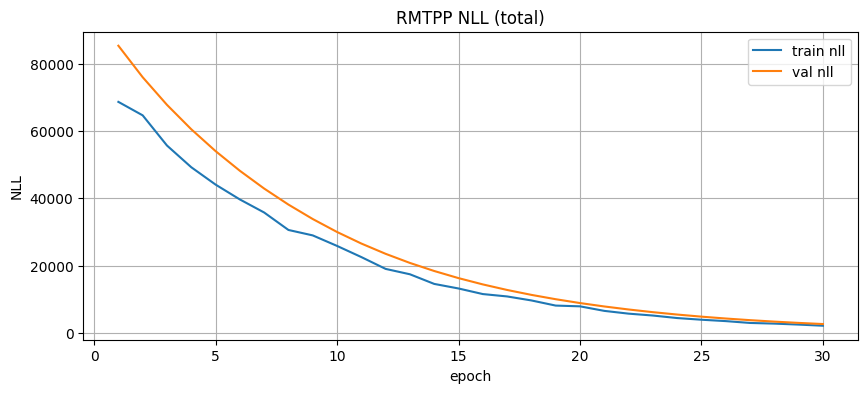

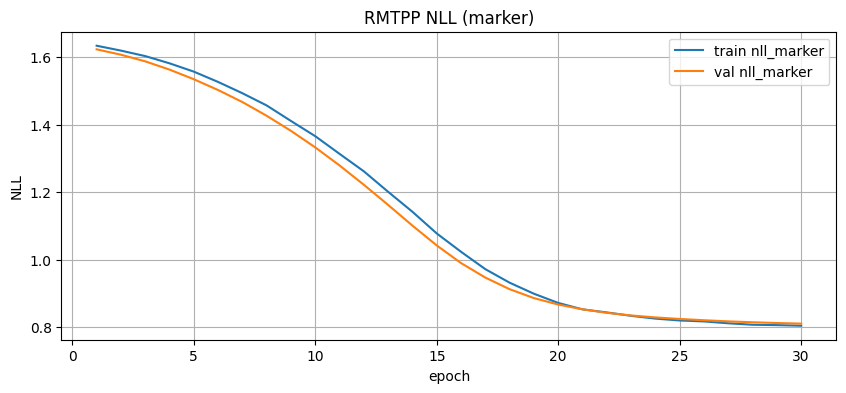

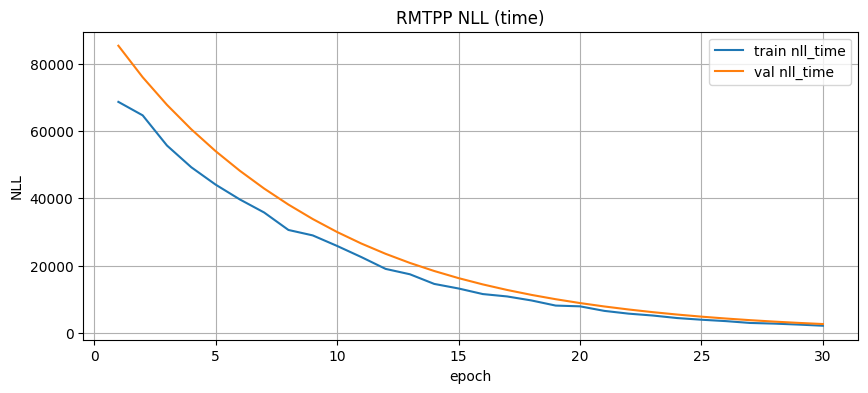

In [42]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(history["train_nll"]) + 1))

plt.figure(figsize=(10, 4))
plt.plot(epochs, history["train_nll"], label="train nll")
plt.plot(epochs, history["val_nll"], label="val nll")
plt.xlabel("epoch")
plt.ylabel("NLL")
plt.title("RMTPP NLL (total)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs, history["train_nll_marker"], label="train nll_marker")
plt.plot(epochs, history["val_nll_marker"], label="val nll_marker")
plt.xlabel("epoch")
plt.ylabel("NLL")
plt.title("RMTPP NLL (marker)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs, history["train_nll_time"], label="train nll_time")
plt.plot(epochs, history["val_nll_time"], label="val nll_time")
plt.xlabel("epoch")
plt.ylabel("NLL")
plt.title("RMTPP NLL (time)")
plt.legend()
plt.grid(True)
plt.show()


## Selecting specific sequence and next event forecasting
select one batch from val_loader then drawing mark distribution (softmax) via final step hidden output.
- mark distribution (softmax)

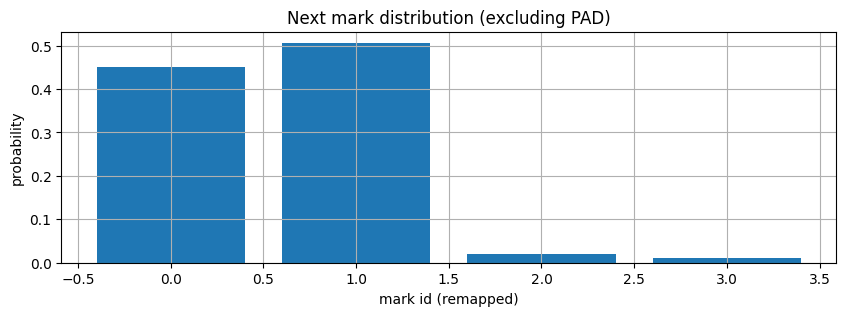

In [43]:
import torch
import matplotlib.pyplot as plt

model.eval()

marks, dts, mask = next(iter(val_loader))
marks = marks.to(device)
dts = dts.to(device)
mask = mask.to(device)

# i번째 시퀀스 선택
i = 0

# 유효 길이
L = int(mask[i].sum().item())
marks_i = marks[i:i+1, :L]   # [1, L]
dts_i = dts[i:i+1, :L]       # [1, L]

with torch.no_grad():
    h = model.forward_hidden(marks_i, dts_i)     # [1, L, H]
    h_last = h[:, -1, :]                         # [1, H]
    logits = model.mark_head(h_last).squeeze(0)  # [K+1]
    probs = torch.softmax(logits, dim=-1).detach().cpu()

# PAD 인덱스는 마지막(K) 이므로 제외하고 보기 권장
probs_no_pad = probs[:-1]

plt.figure(figsize=(10, 3))
plt.bar(range(len(probs_no_pad)), probs_no_pad.numpy())
plt.xlabel("mark id (remapped)")
plt.ylabel("probability")
plt.title("Next mark distribution (excluding PAD)")
plt.grid(True)
plt.show()

## Drawing the 'time model' itself: intensity / density / survival
The time part of the RMTPP is given by the last hidden ${h_j}$

- ${a = v^Th_j + b}$
- ${w > 0}$
- ${\lambda(u) = exp(a = wu)}$

### intensity ${\lambda(u)}$ Graph

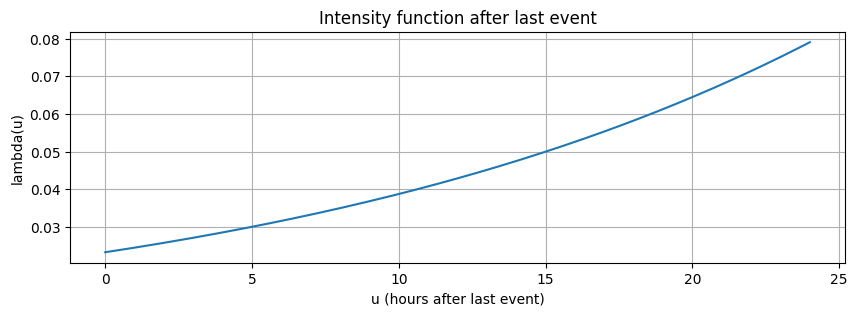

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def intensity_curve(model, h_last, u_max=3600.0, n=200):
    # u: [n]
    u = torch.linspace(0.0, u_max, n, device=h_last.device)
    w = model._w_pos()  # scalar
    a = model.v_t(h_last).squeeze(-1) + model.b_t  # [1]
    lam = torch.exp(torch.clamp(a + w * u, max=model.cfg.exp_clamp))
    return u.detach().cpu().numpy(), lam.detach().cpu().numpy()

with torch.no_grad():
    u, lam = intensity_curve(model, h_last, u_max=24.0, n=200)

plt.figure(figsize=(10, 3))
plt.plot(u, lam)
plt.xlabel("u (hours after last event)")
plt.ylabel("lambda(u)")
plt.title("Intensity function after last event")
plt.grid(True)
plt.show()


### density ${f(u)}$ Graph (dt distribution)

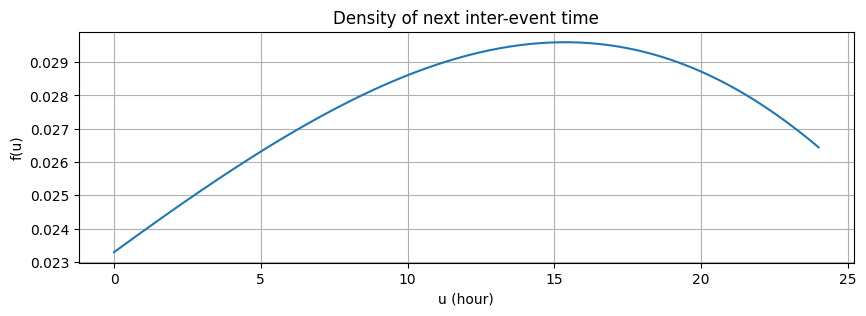

In [45]:
def density_curve(model, h_last, u_max=3600.0, n=200):
    u = torch.linspace(0.0, u_max, n, device=h_last.device)  # [n]
    w = model._w_pos()
    a = model.v_t(h_last).squeeze(-1) + model.b_t            # [1]

    # log f(u) closed-form: a + w u + exp(a)/w - exp(a+w u)/w
    wd = w * u
    exp_a = torch.exp(torch.clamp(a, max=model.cfg.exp_clamp))
    exp_a_wd = torch.exp(torch.clamp(a + wd, max=model.cfg.exp_clamp))
    logf = (a + wd) + (exp_a / w) - (exp_a_wd / w)
    f = torch.exp(torch.clamp(logf, max=model.cfg.exp_clamp))
    return u.detach().cpu().numpy(), f.detach().cpu().numpy()

with torch.no_grad():
    u, f = density_curve(model, h_last, u_max=24.0, n=200)

plt.figure(figsize=(10, 3))
plt.plot(u, f)
plt.xlabel("u (hour)")
plt.ylabel("f(u)")
plt.title("Density of next inter-event time")
plt.grid(True)
plt.show()


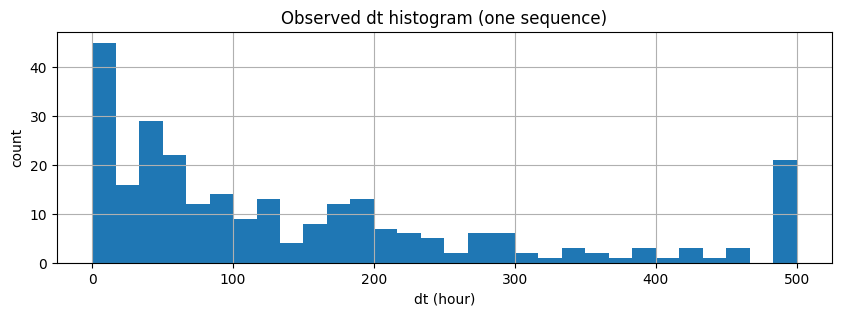

In [46]:
import matplotlib.pyplot as plt

dt_obs = dts_i.squeeze(0).detach().cpu().numpy()  # [L]
# drop first dt(0)
dt_obs = dt_obs[1:]

plt.figure(figsize=(10, 3))
plt.hist(dt_obs, bins=30)
plt.xlabel("dt (hour)")
plt.ylabel("count")
plt.title("Observed dt histogram (one sequence)")
plt.grid(True)
plt.show()


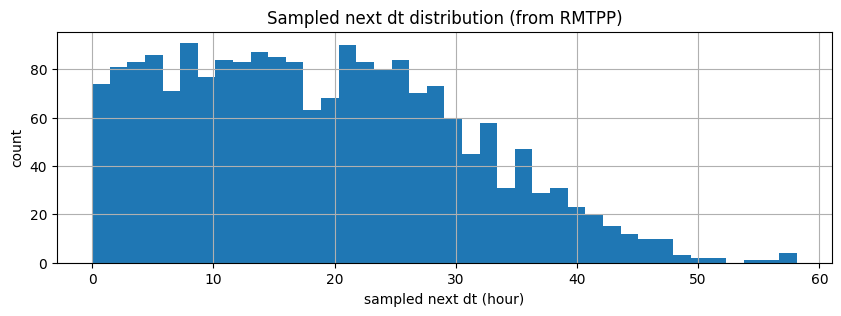

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import torch

with torch.no_grad():
    # 동일 h_last로 N번 샘플링
    N = 2000
    h_rep = h_last.repeat(N, 1)         # [N, H]
    dt_samp = model.sample_next_dt(h_rep).detach().cpu().numpy()

plt.figure(figsize=(10, 3))
plt.hist(dt_samp, bins=40)
plt.xlabel("sampled next dt (hour)")
plt.ylabel("count")
plt.title("Sampled next dt distribution (from RMTPP)")
plt.grid(True)
plt.show()


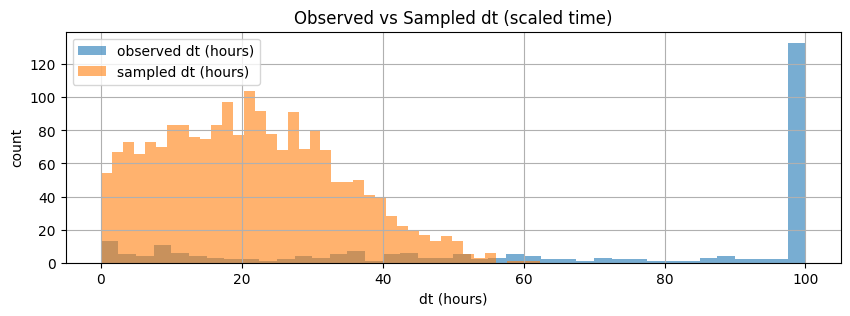

Observed dt (hours): [ 95.15833282 100.         100.        ]
Sampled  dt (hours): [20.49260139 38.2622963  50.71550636]


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import torch

model.eval()

# val 배치 1개에서 1개 시퀀스 선택
marks, dts, mask = next(iter(val_loader))
marks = marks.to(device); dts = dts.to(device); mask = mask.to(device)

i = 0
L = int(mask[i].sum().item())
marks_i = marks[i:i+1, :L]
dts_i = dts[i:i+1, :L]

# 관측 dt (hours)
dt_obs_h = dts_i.squeeze(0).detach().cpu().numpy()[1:]  # d0 제외

# 모델 샘플링 dt (hours)
with torch.no_grad():
    h = model.forward_hidden(marks_i, dts_i)
    h_last = h[:, -1, :]
    N = 2000
    dt_samp_h = model.sample_next_dt(h_last.repeat(N, 1)).detach().cpu().numpy()

plt.figure(figsize=(10, 3))
plt.hist(dt_obs_h, bins=40, alpha=0.6, label="observed dt (hours)")
plt.hist(dt_samp_h, bins=40, alpha=0.6, label="sampled dt (hours)")
plt.xlabel("dt (hours)")
plt.ylabel("count")
plt.title("Observed vs Sampled dt (scaled time)")
plt.grid(True)
plt.legend()
plt.show()

print("Observed dt (hours):", np.quantile(dt_obs_h, [0.5, 0.9, 0.99]))
print("Sampled  dt (hours):", np.quantile(dt_samp_h, [0.5, 0.9, 0.99]))


In [15]:
marks, dts, mask = next(iter(train_loader))
marks = marks.to(device); dts = dts.to(device); mask = mask.to(device)

with torch.no_grad():
    h = model.forward_hidden(marks, dts)
    h_j = h[:, :-1, :]
    dt_next = dts[:, 1:].float()

    a = model.v_t(h_j).squeeze(-1) + model.b_t
    w = model._w_pos()
    wd = w * dt_next

print("dt_next min/max:", float(dt_next.min()), float(dt_next.max()))
print("a min/max:", float(a.min()), float(a.max()))
print("w:", float(w))
print("wd min/max:", float(wd.min()), float(wd.max()))
print("max exp(a):", float(torch.exp(torch.clamp(a, max=20.0)).max()))
print("max exp(a+wd):", float(torch.exp(torch.clamp(a + wd, max=20.0)).max()))


dt_next min/max: 0.0 24.0
a min/max: -3.686474323272705 0.31240323185920715
w: 0.04851918667554855
wd min/max: 0.0 1.1644604206085205
max exp(a): 1.3667056560516357
max exp(a+wd): 3.326878786087036
